# v2 - bottom tracking: W sign test, and Parcels vs an in-house tracker

Two questions:

1. **Is the vertical sign inverted?** v1 measured `dz/dt = +1.08 W`, so Parcels adds W to
   `depth`, and `depth` grows downward. GLORYS' `vovecrtz` is positive *upward*. In a cul-de-sac
   bottom cell continuity forces `w_k > 0` with horizontal inflow, so those particles must rise -
   and they sank. Here the same run is repeated with `-W` to confirm.

2. **Does an independent integrator agree?** `JackMacklarvae.m` is re-implemented in numpy and
   run on the same fields and seeds. It is a different scheme (trapezoidal in *index* space, with
   `dz` from the partial-cell `e3t`), so if the two trackers behave the same way the cause is the
   fields and the convention, not Parcels.

In [1]:
n_particles        = 200
run_time_days      = 28
time_step_minutes  = 20
out_put_step_hours = 6

ref_date = "1993-01-01"
offset   = 1
rdm_seed = 110987

Hgr, Zgr = "Hgr_cmesh.nc", "Zgr_cmesh2.nc"
FIELDS   = dict(U="U_1993-01b.nc", V="V_1993-01b.nc", W="W_1993-01b.nc")

SHELF_H = (20.0, 100.0)
BOX     = dict(lon=(-52, -46), lat=(-1.5, 4.5))

out_root    = "bottom_tracks_v2"
FORCE_RERUN = False

In [2]:
import os, sys, shutil, contextlib
import numpy as np
import xarray as xr
from datetime import timedelta
from scipy.spatial import cKDTree
from scipy.ndimage import map_coordinates
import matplotlib.pyplot as plt

from parcels import FieldSet, ParticleSet, JITParticle

@contextlib.contextmanager
def quiet():
    sys.stdout.flush()
    saved, devnull = os.dup(1), os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 1); yield
    finally:
        os.dup2(saved, 1); os.close(devnull); os.close(saved)

start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
nout = int(run_time_days * 24 / out_put_step_hours) + 1
print(f"{start_time} + {run_time_days} d   dt={time_step_minutes} min   {nout} outputs")

1993-01-02 + 28 d   dt=20 min   113 outputs


## 1. Grid and seeds (identical to v1)

In [3]:
zgr = xr.open_dataset(Zgr).squeeze()
hgr = xr.open_dataset(Hgr).squeeze()
mbathy  = zgr.mbathy.values.astype(int)
gdepw_0 = zgr.gdepw_0.squeeze().values.astype("f8")
gdept_0 = zgr.gdept_0.squeeze().values.astype("f8")
e3t_0   = zgr.e3t_0.squeeze().values.astype("f8")
e3t_ps  = zgr.e3t_ps.values.astype("f8")
lon2d, lat2d = zgr.nav_lon.values.astype("f8"), zgr.nav_lat.values.astype("f8")
e1t, e2t = hgr.e1t.values.astype("f8"), hgr.e2t.values.astype("f8")
nz, ny, nx = len(e3t_0), *mbathy.shape

kk   = np.arange(nz)[:, None, None]
wet  = (kk + 1) <= mbathy
e3t  = np.where(kk + 1 <= mbathy - 1, e3t_0[:, None, None], e3t_ps)
e3t  = np.where(wet, e3t, 0.0)
kb   = np.clip(mbathy - 1, 0, nz - 1)
H    = gdepw_0[kb] + np.where(mbathy > 0, e3t_ps, 0.0)
zbot = gdepw_0[kb] + 0.5 * np.where(mbathy > 0, e3t_ps, 0.0)

wj, wi = np.where(mbathy > 0)
tree   = cKDTree(np.column_stack([lon2d[wj, wi], lat2d[wj, wi]]))
Hw     = H[wj, wi]
def seabed_at(lo, la):
    f = np.column_stack([np.ravel(lo), np.ravel(la)]); ok = np.isfinite(f).all(1)
    o = np.full(len(f), np.nan)
    if ok.any(): o[ok] = Hw[tree.query(f[ok])[1]]
    return o.reshape(np.shape(lo))

shelf = ((mbathy > 0) & (H > SHELF_H[0]) & (H < SHELF_H[1])
         & (lon2d > BOX["lon"][0]) & (lon2d < BOX["lon"][1])
         & (lat2d > BOX["lat"][0]) & (lat2d < BOX["lat"][1]))
rng = np.random.default_rng(rdm_seed)
jj, ii = np.where(shelf)
sel = rng.choice(len(jj), size=n_particles, replace=len(jj) < n_particles)
pj, pi = jj[sel], ii[sel]
start_lon, start_lat = lon2d[pj, pi], lat2d[pj, pi]
start_depth = zbot[pj, pi]
assert np.all(start_depth < H[pj, pi])
print(f"{n_particles} seeds, depth {start_depth.min():.2f}-{start_depth.max():.2f} m, "
      f"bed {H[pj,pi].min():.2f}-{H[pj,pi].max():.2f} m")

200 seeds, depth 20.49-91.87 m, bed 21.00-98.98 m


## 2. Parcels, with W and with -W

In [4]:
def AdvectionRK4_3D_negW(particle, fieldset, time):  # pragma: no cover
    '''RK4 with the vertical velocity negated: dz/dt = -W, i.e. NEMO W positive upward.'''
    (u1, v1, w1) = fieldset.UVW[particle]
    lon1 = particle.lon + u1 * 0.5 * particle.dt
    lat1 = particle.lat + v1 * 0.5 * particle.dt
    dep1 = particle.depth - w1 * 0.5 * particle.dt
    (u2, v2, w2) = fieldset.UVW[time + 0.5 * particle.dt, dep1, lat1, lon1, particle]
    lon2 = particle.lon + u2 * 0.5 * particle.dt
    lat2 = particle.lat + v2 * 0.5 * particle.dt
    dep2 = particle.depth - w2 * 0.5 * particle.dt
    (u3, v3, w3) = fieldset.UVW[time + 0.5 * particle.dt, dep2, lat2, lon2, particle]
    lon3 = particle.lon + u3 * particle.dt
    lat3 = particle.lat + v3 * particle.dt
    dep3 = particle.depth - w3 * particle.dt
    (u4, v4, w4) = fieldset.UVW[time + particle.dt, dep3, lat3, lon3, particle]
    particle_dlon += (u1 + 2 * u2 + 2 * u3 + u4) / 6 * particle.dt  # noqa
    particle_dlat += (v1 + 2 * v2 + 2 * v3 + v4) / 6 * particle.dt  # noqa
    particle_ddepth -= (w1 + 2 * w2 + 2 * w3 + w4) / 6 * particle.dt  # noqa


def CheckError(particle, fieldset, time):  # pragma: no cover
    if particle.state >= 50:
        particle.delete()


from parcels import AdvectionRK4_3D

def run_parcels(tag, kernel):
    out = os.path.join(out_root, f"{tag}.zarr")
    if os.path.exists(out) and not FORCE_RERUN:
        print(f"  reusing {out}"); return out
    if os.path.exists(out): shutil.rmtree(out)
    os.makedirs(out_root, exist_ok=True)
    fn = {v: {"data": FIELDS[v], "lon": Hgr, "lat": Hgr, "depth": FIELDS["W"]}
          for v in ("U", "V", "W")}
    fs = FieldSet.from_netcdf(
        fn, {"U": "vozocrtx", "V": "vomecrty", "W": "vovecrtz"},
        {v: {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"}
         for v in ("U", "V", "W")},
        interp_method={v: "cgrid_velocity" for v in ("U", "V", "W")},
        deferred_load=True, allow_time_extrapolation=False, gridindexingtype="nemo")
    ps = ParticleSet(fs, JITParticle, lon=start_lon, lat=start_lat,
                     depth=start_depth, time=np.datetime64(start_time))
    pf = ps.ParticleFile(name=out, outputdt=timedelta(hours=out_put_step_hours),
                         chunks=(n_particles, nout + 2))
    with quiet():
        ps.execute([kernel, CheckError], runtime=timedelta(days=run_time_days),
                   dt=timedelta(minutes=time_step_minutes), output_file=pf)
    return out

P = {}
for tag, kern in [("parcels_posW", AdvectionRK4_3D), ("parcels_negW", AdvectionRK4_3D_negW)]:
    print(f"===== {tag} =====")
    P[tag] = run_parcels(tag, kern)
print("done")

===== parcels_posW =====
  reusing bottom_tracks_v2/parcels_posW.zarr
===== parcels_negW =====
  reusing bottom_tracks_v2/parcels_negW.zarr
done


## 3. The in-house tracker, after `JackMacklarvae.m`

Faithful to the scheme in that script:

- state is a **fractional grid index** `(k, j, i)`, not a physical position;
- velocities are interpolated trilinearly at the particle's index (`interp3` -> `map_coordinates`);
- the step is trapezoidal: a first guess, then
  `x += (u1 + u2) / (dx1 + dx2) * dt` - the mean velocity over the mean cell size;
- `w` is averaged from w-levels onto T-levels, `winow = 0.5*(w[:-1] + w[1:])`;
- daily fields are interpolated linearly in time.

`dz3d` in the original is one value per level (`repmat(shiftdim(dz(:),-2), ...)`) with no
partial cells and no land mask, so it is kept that way here. U and V are averaged from the
C-grid faces to T-points, since the scheme assumes collocated velocities.

In [5]:
# work on a sub-box to keep the fields in memory
mlon = (lon2d > -62) & (lon2d < -40) & (lat2d > -4) & (lat2d < 14)
bj, bi = np.where(mlon)
J0, J1, I0, I1 = bj.min(), bj.max() + 1, bi.min(), bi.max() + 1
sy, sx = J1 - J0, I1 - I0
print(f"sub-box j[{J0}:{J1}] i[{I0}:{I1}] -> {sy} x {sx}")

LON_B, LAT_B = lon2d[J0:J1, I0:I1], lat2d[J0:J1, I0:I1]
DX = np.broadcast_to(e1t[J0:J1, I0:I1], (nz, sy, sx)).copy()
DY = np.broadcast_to(e2t[J0:J1, I0:I1], (nz, sy, sx)).copy()
# faithful to the .m: dz3d = repmat(shiftdim(dz(:),-2), [ny nx 1]) -- one value per level,
# no partial cells and no land mask. (Masking it to NaN in rock kills every bottom particle
# on the first step, since map_coordinates blends the NaN in from the dry cell below.)
DZ = np.broadcast_to(e3t_0[:, None, None], (nz, sy, sx)).copy()

dsU = xr.open_dataset(FIELDS["U"]).vozocrtx
dsV = xr.open_dataset(FIELDS["V"]).vomecrty
dsW = xr.open_dataset(FIELDS["W"]).vovecrtz

def load_day(d):
    '''U,V on T-points and W on T-levels, as the .m script expects.'''
    u = np.nan_to_num(dsU.isel(time_counter=d, y=slice(J0, J1), x=slice(I0, I1)).values).astype("f8")
    v = np.nan_to_num(dsV.isel(time_counter=d, y=slice(J0, J1), x=slice(I0, I1)).values).astype("f8")
    w = np.nan_to_num(dsW.isel(time_counter=d, y=slice(J0, J1), x=slice(I0, I1)).values).astype("f8")
    uT = np.empty_like(u); uT[:, :, 1:] = 0.5 * (u[:, :, :-1] + u[:, :, 1:]); uT[:, :, 0] = u[:, :, 0]
    vT = np.empty_like(v); vT[:, 1:, :] = 0.5 * (v[:, :-1, :] + v[:, 1:, :]); vT[:, 0, :] = v[:, 0, :]
    wT = np.empty_like(w); wT[:-1] = 0.5 * (w[:-1] + w[1:]); wT[-1] = w[-1]
    return uT, vT, wT
print("field loader ready")

sub-box j[72:290] i[397:660] -> 218 x 263
field loader ready


In [6]:
def interp3(fld, k, j, i):
    return map_coordinates(fld, np.vstack([k, j, i]), order=1, mode="nearest")

def run_inhouse(wsign):
    dt = time_step_minutes * 60.0
    nsub = int(round(out_put_step_hours * 3600 / dt))
    k = np.interp(start_depth, gdept_0, np.arange(nz)).astype("f8")
    j = (pj - J0).astype("f8")
    i = (pi - I0).astype("f8")
    alive = np.ones(n_particles, bool)
    rec = np.full((n_particles, nout, 3), np.nan)
    rec[:, 0, :] = np.column_stack([k, j, i])

    cur = -1; U1 = V1 = W1 = U2 = V2 = W2 = None
    step = 0
    for ob in range(1, nout):
        for _ in range(nsub):
            tsec = step * dt
            d = int(tsec // 86400)
            if d != cur:
                cur = d
                U1, V1, W1 = load_day(offset + d)
                U2, V2, W2 = load_day(min(offset + d + 1, dsU.sizes["time_counter"] - 1))
            a = (tsec - d * 86400) / 86400.0
            u = (1 - a) * U1 + a * U2; v = (1 - a) * V1 + a * V2; w = (1 - a) * W1 + a * W2

            u1 = interp3(u, k, j, i); v1 = interp3(v, k, j, i)
            w1 = wsign * interp3(w, k, j, i)
            dx1 = interp3(DX, k, j, i); dy1 = interp3(DY, k, j, i); dz1 = interp3(DZ, k, j, i)
            kg = k + w1 / dz1 * dt; jg = j + v1 / dy1 * dt; ig = i + u1 / dx1 * dt
            kg = np.clip(kg, 0, nz - 1); jg = np.clip(jg, 0, sy - 1); ig = np.clip(ig, 0, sx - 1)

            u2 = interp3(u, kg, jg, ig); v2 = interp3(v, kg, jg, ig)
            w2 = wsign * interp3(w, kg, jg, ig)
            dx2 = interp3(DX, kg, jg, ig); dy2 = interp3(DY, kg, jg, ig); dz2 = interp3(DZ, kg, jg, ig)

            i = np.where(alive, i + (u1 + u2) / (dx1 + dx2) * dt, i)
            j = np.where(alive, j + (v1 + v2) / (dy1 + dy2) * dt, j)
            k = np.where(alive, k + (w1 + w2) / (dz1 + dz2) * dt, k)
            alive &= np.isfinite(k) & np.isfinite(j) & np.isfinite(i)
            k = np.clip(np.nan_to_num(k, nan=0.0), 0, nz - 1)
            j = np.clip(np.nan_to_num(j, nan=0.0), 0, sy - 1)
            i = np.clip(np.nan_to_num(i, nan=0.0), 0, sx - 1)
            step += 1
        rec[:, ob, 0] = np.where(alive, k, np.nan)
        rec[:, ob, 1] = np.where(alive, j, np.nan)
        rec[:, ob, 2] = np.where(alive, i, np.nan)
    return rec

IH = {}
for tag, s in [("inhouse_posW", +1.0), ("inhouse_negW", -1.0)]:
    print(f"===== {tag} =====")
    IH[tag] = run_inhouse(s)
    print(f"  {int(np.isfinite(IH[tag][:, -1, 0]).sum())} of {n_particles} still tracked")

===== inhouse_posW =====


  200 of 200 still tracked
===== inhouse_negW =====


  200 of 200 still tracked


In [7]:
# index -> physical coordinates
def to_phys(rec):
    k, j, i = rec[..., 0], rec[..., 1], rec[..., 2]
    f = np.isfinite(k)
    lo = np.full(k.shape, np.nan); la = np.full(k.shape, np.nan); z = np.full(k.shape, np.nan)
    lo[f] = map_coordinates(LON_B, np.vstack([j[f], i[f]]), order=1, mode="nearest")
    la[f] = map_coordinates(LAT_B, np.vstack([j[f], i[f]]), order=1, mode="nearest")
    z[f]  = np.interp(k[f], np.arange(nz), gdept_0)
    return dict(lon=lo, lat=la, z=z, bed=seabed_at(lo, la),
                t=np.arange(k.shape[1]) * out_put_step_hours / 24.0)

TRK = {}
for tag, pth in P.items():
    d = xr.open_zarr(pth).compute()
    lat = d.lat.values; keep = np.isfinite(lat).any(axis=0)
    lo, la = d.lon.values[:, keep], lat[:, keep]
    TRK[tag] = dict(lon=lo, lat=la, z=np.where(np.isfinite(la), d.z.values[:, keep], np.nan),
                    bed=seabed_at(lo, la),
                    t=np.arange(keep.sum()) * out_put_step_hours / 24.0)
for tag, rec in IH.items():
    TRK[tag] = to_phys(rec)
for tag, v in TRK.items():
    print(f"{tag:<14} {v['lon'].shape[0]} traj, {v['lon'].shape[1]} outputs")

parcels_posW   200 traj, 112 outputs
parcels_negW   200 traj, 112 outputs
inhouse_posW   200 traj, 113 outputs
inhouse_negW   200 traj, 113 outputs


## 4. The sign test

In [8]:
print(f"{'run':<15}{'ended below the bed':>22}{'median h.a.b. at day 28':>26}")
for tag, v in TRK.items():
    nb_ = np.isfinite(v["lat"]).sum(axis=1)
    last = np.where(nb_ > 0, nb_ - 1, 0); r = np.arange(len(last))
    hab = v["bed"][r, last] - v["z"][r, last]
    print(f"{tag:<15}{int(np.nansum(hab < 0)):>13} of {int(np.isfinite(hab).sum()):<8}"
          f"{np.nanmedian(hab):>26.2f}")
print("h.a.b. = height above the local seabed [m]; negative means inside the seafloor")

run               ended below the bed   median h.a.b. at day 28
parcels_posW             168 of 200                          -4.57
parcels_negW               6 of 200                         172.18
inhouse_posW             180 of 200                         -11.76
inhouse_negW              62 of 200                          39.25
h.a.b. = height above the local seabed [m]; negative means inside the seafloor


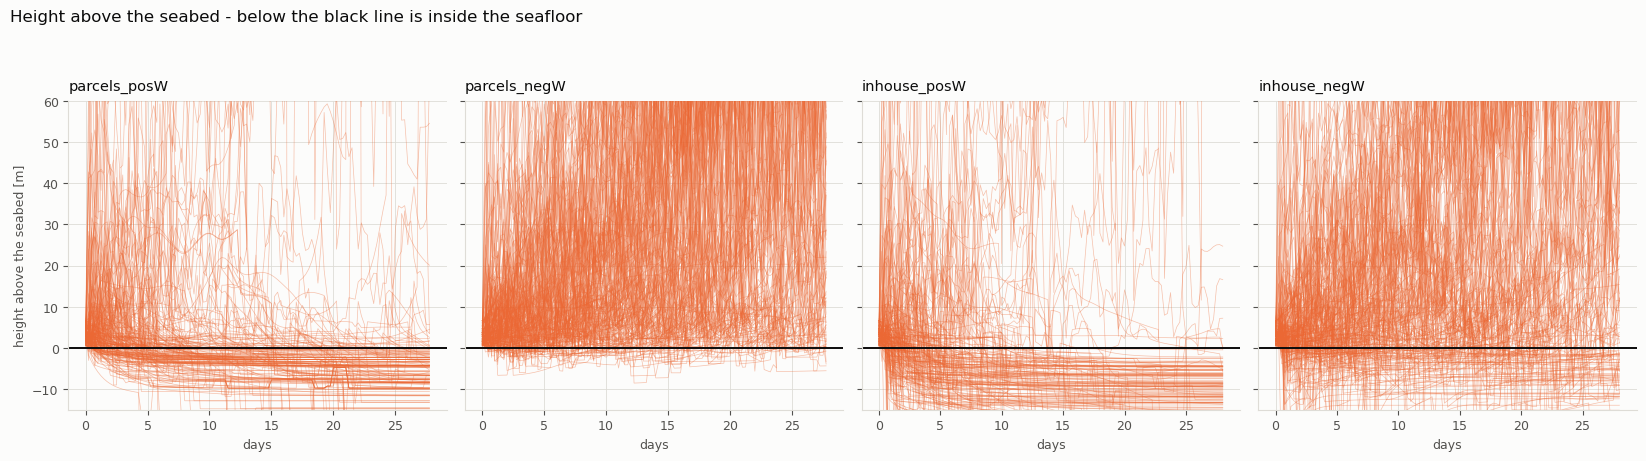

In [9]:
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.facecolor": SURF,
    "figure.facecolor": SURF, "axes.titlecolor": INK})

order = ["parcels_posW", "parcels_negW", "inhouse_posW", "inhouse_negW"]
fig, axs = plt.subplots(1, 4, figsize=(16.5, 4.6), sharey=True)
for ax, tag in zip(axs, order):
    v = TRK[tag]
    ax.plot(v["t"], (v["bed"] - v["z"]).T, lw=0.5, color="#eb6834", alpha=0.4)
    ax.axhline(0, lw=1.4, color="#0b0b0b")
    ax.set_title(tag, loc="left", fontsize=10.5, pad=8)
    ax.set_xlabel("days")
    ax.grid(True, lw=0.6, color=GRID); ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
axs[0].set_ylabel("height above the seabed [m]")
axs[0].set_ylim(-15, 60)
fig.suptitle("Height above the seabed - below the black line is inside the seafloor",
             x=0.006, ha="left", fontsize=12, color=INK, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("v2_sign_test.png", dpi=170, facecolor=SURF)
plt.show()

## 5. Parcels vs the in-house tracker

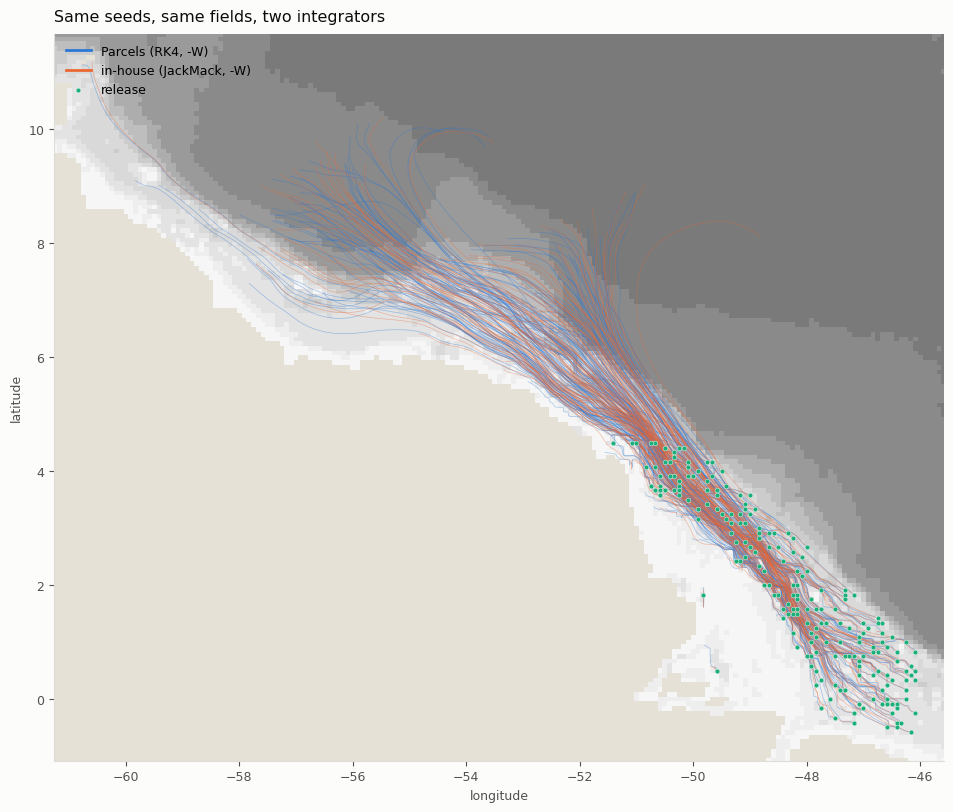

In [10]:
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
allon = np.concatenate([TRK[t]["lon"].ravel() for t in ("parcels_negW", "inhouse_negW")])
allat = np.concatenate([TRK[t]["lat"].ravel() for t in ("parcels_negW", "inhouse_negW")])
x0, x1 = np.nanmin(allon) - 0.5, np.nanmax(allon) + 0.5
y0, y1 = np.nanmin(allat) - 0.5, np.nanmax(allat) + 0.5
m = (lon2d >= x0) & (lon2d <= x1) & (lat2d >= y0) & (lat2d <= y1)
gj, gi = np.where(m); Js, Is = slice(gj.min(), gj.max()+1), slice(gi.min(), gi.max()+1)
LEV = [0, 10, 20, 50, 100, 200, 500, 1000, 2000, 4000, 6000]
bc = ListedColormap(mpl.colormaps["Greys"](np.linspace(0.08, 0.6, len(LEV)-1))); bc.set_bad("#e6e1d6")
bn = BoundaryNorm(LEV, bc.N)

fig, ax = plt.subplots(figsize=(11.5, 8.2))
ax.set_facecolor("#e6e1d6")
ax.pcolormesh(lon2d[Js, Is], lat2d[Js, Is],
              np.where(mbathy[Js, Is] > 0, H[Js, Is], np.nan), cmap=bc, norm=bn,
              shading="auto", zorder=0)
for tag, col, lab in [("parcels_negW", "#2a78d6", "Parcels (RK4, -W)"),
                      ("inhouse_negW", "#eb6834", "in-house (JackMack, -W)")]:
    v = TRK[tag]
    ax.plot(v["lon"].T, v["lat"].T, lw=0.5, color=col, alpha=0.4, zorder=2)
    ax.plot([], [], lw=2, color=col, label=lab)
ax.scatter(start_lon, start_lat, s=12, color="#1baf7a", edgecolor="white",
           linewidth=0.3, zorder=4, label="release")
ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
ax.set_aspect(1 / np.cos(np.deg2rad(np.mean([y0, y1]))))
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("Same seeds, same fields, two integrators", loc="left", fontsize=11.5, pad=9)
for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig("v2_parcels_vs_inhouse.png", dpi=170, facecolor=SURF)
plt.show()